In [17]:
myhome = '/gscratch/ssmc/USRS/PSI/Ben'
gsc_stefano = '/gscratch/ssmc/USRS/PSI/Stefano'
process_output = myhome + '/projects/Ecy25_analysis/data/bentest'

ver_netcdf_output_wc = gsc_stefano + '/projects/KingCounty_Ecy25/SSM_data/whidbey/DOXG/exist/wc/daily_mean_DOXG_wc.nc'
process_netcdf_output_wc = process_output + '/DOXG/wqm_baseline/wc/daily_mean_DOXG_wc.nc'

import xarray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
ds_process = xarray.open_dataset(process_netcdf_output_wc, engine='netcdf4')
ds_process

<xarray.Dataset> Size: 231MB
Dimensions:             (dim_0: 360, dim_1: 10, dim_2: 16012)
Dimensions without coordinates: dim_0, dim_1, dim_2
Data variables:
    DOXG_daily_mean_wc  (dim_0, dim_1, dim_2) float32 231MB ...

In [8]:
ds_ver = xarray.open_dataset(ver_netcdf_output_wc, engine='netcdf4')
ds_ver

<xarray.Dataset> Size: 231MB
Dimensions:             (dim_0: 361, dim_1: 10, dim_2: 16012)
Dimensions without coordinates: dim_0, dim_1, dim_2
Data variables:
    DOXG_daily_mean_wc  (dim_0, dim_1, dim_2) float32 231MB ...

So there's already a problem here, the number of days between the two files doesn't match. Let's build a simple comparison routine on random dates/nodes over the entire water column, and let it run just one time to see what it shows.

In [16]:
N = 1000

dates = np.random.randint(0, 359, N)
nodes = np.random.randint(0, 16011, N)

for i in range(N):
    data_process = ds_process['DOXG_daily_mean_wc'][dates[i], :, nodes[i]]
    data_ver = ds_ver['DOXG_daily_mean_wc'][dates[i], :, nodes[i]]
    display(data_process - data_ver)
    break

<xarray.DataArray 'DOXG_daily_mean_wc' (dim_1: 10)> Size: 40B
array([ 0.46579266, -0.04231453, -0.01521111,  0.04504681,  0.0613718 ,
        0.01860046,  0.02060413,  0.01686287, -0.00915337, -0.0156188 ],
      dtype=float32)
Dimensions without coordinates: dim_1

That's a problem, they don't line up. We need to investigate why. Since we already know there's an extra day, maybe there's a misalignment on time. Start by plotting the first random node at the bottom as a time series between both files and look for patterns.

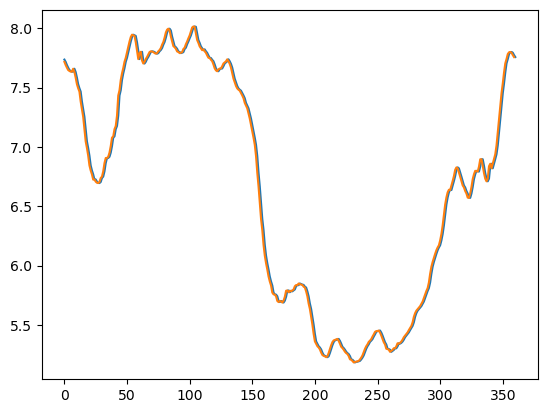

In [18]:
fig, ax = plt.subplots()
days = np.arange(361)
ax.plot(days, ds_ver['DOXG_daily_mean_wc'][:,-1,nodes[0]])
ax.plot(days[:-1], ds_process['DOXG_daily_mean_wc'][:,-1,nodes[0]])

This plot above indeed suggests we are looking at the same data but with a time shift. Now let's look at just a few days of the output values at that node on the bottom.

In [21]:
data_ver = ds_ver['DOXG_daily_mean_wc'][:10,-1,nodes[0]].to_numpy()
data_process = ds_process['DOXG_daily_mean_wc'][:10,-1,nodes[0]].to_numpy()
pd.DataFrame({"Veronica's output": data_ver, "Rachael's output": data_process})

,Veronica's output,Rachael's output
0,7.735476,7.716584
1,7.716584,7.690069
2,7.690069,7.667739
3,7.667739,7.647719
4,7.647719,7.639900
5,7.639900,7.634068
6,7.634068,7.633568
7,7.633568,7.658432
8,7.658432,7.630713
9,7.630713,7.583691


Okay, we've conclusively shown here that Veronica's script produces output for one extra day at the beginning, ie Rachael's script has one extra day removed for model spinup. Looking at the above columns with a one-day shift, they're identical.

Now aside from that problem, let's show the files truly have identical data by re-running the random day/node comparisons with a one-day offset for Veronica's output.

Start by doing the full run *without* the offset as a positive control for difference detection.

In [23]:
data_diffs = np.zeros(N)
for i in range(N):
    data_process = ds_process['DOXG_daily_mean_wc'][dates[i], :, nodes[i]]
    data_ver = ds_ver['DOXG_daily_mean_wc'][dates[i], :, nodes[i]]
    data_diffs[i] = np.max(np.abs(data_process) - np.abs(data_ver))
pd.DataFrame({"Day": dates, "Node": nodes, "Mean Abs Difference": data_diffs})

,Day,Node,Mean Abs Difference
0,109,2832,0.465793
1,16,3421,0.167949
2,142,9412,0.091860
3,358,3386,-0.020753
4,245,2152,0.054270
...,...,...,...
995,209,7707,0.200952
996,5,15390,0.048120
997,248,12839,0.747616
998,329,11723,-0.124553


Yep, this code should be able to detect any differences. Now run it for real, just with a one-day offset on Veronica's output.

In [25]:
data_diffs = np.zeros(N)
for i in range(N):
    data_process = ds_process['DOXG_daily_mean_wc'][dates[i], :, nodes[i]]
    data_ver = ds_ver['DOXG_daily_mean_wc'][dates[i]+1, :, nodes[i]]
    data_diffs[i] = np.max(np.abs(data_process) - np.abs(data_ver))
qa_df = pd.DataFrame({"Day": dates, "Node": nodes, "Mean Abs Difference": data_diffs})
display(f'Max difference: {qa_df['Mean Abs Difference'].max()}')
qa_df.head()

'Max difference: 0.0'

,Day,Node,Mean Abs Difference
0,109,2832,0.0
1,16,3421,0.0
2,142,9412,0.0
3,358,3386,0.0
4,245,2152,0.0


And we have thus shown the outputs produced through two different methods, aside from a off-by-one issue on the validation script, are identical.

# QA Against Ecology Published Values

The following data was taken from Ecology's [map view](https://gis.ecology.wa.gov/portal/apps/experiencebuilder/experience/?id=a4f911186f7d4ee89252f8089463886a&page=Home&views=Layers#data_s=id%3AdataSource_2-1974253a524-layer-35-199c95acdf0-layer-76%3A496), looking for 303d rectangles that contained only a single TCE, then noting the TCE number and predicted daily minimum DO concentration under the existing condition. Although these numbers are heavily rounded, we should be able to retrieve the same values from the intermediate netCDF file.

In [40]:
known_ecol_data = pd.DataFrame({
    'TCE': [11500, 13478, 11406, 15218],
    '303d rect': ['47122F9J8', '47123D1G5', '47122G9A7', '47122B8D2'],
    'MinDO': [1.7, 1.2, 1.8, 4.7]
})

In [41]:
process_netcdf_output_wc_min = process_output + '/DOXG/wqm_baseline/wc/daily_min_DOXG_wc.nc'
ds_process_min = xarray.open_dataset(process_netcdf_output_wc_min, engine='netcdf4')

In [43]:
extracted_mindos = np.zeros(len(known_ecol_data))
for i,row in known_ecol_data.iterrows():
    extracted_mindos[i] = ds_process_min['DOXG_daily_min_wc'][:,:,row['TCE']-1].min()
known_ecol_data['MinDO Extracted'] = extracted_mindos
known_ecol_data

,TCE,303d rect,MinDO,MinDO Extracted
0,11500,47122F9J8,1.7,1.73432
1,13478,47123D1G5,1.2,1.16784
2,11406,47122G9A7,1.8,1.82587
3,15218,47122B8D2,4.7,4.66070


Yes, all of the above round to the values given on Ecology's map viewer.